In [ ]:
import json
import os

import matplotlib.pyplot as plt
import pandas as pd
from dotenv import load_dotenv, find_dotenv

from doc_chat.evaluation.rag_judge_agent import evaluate_response
from doc_chat.llm import create_llm
from doc_chat.rag.citation_retrieval_chain import CitationRetrievalChain
from doc_chat.rag.document_loader import DocumentLoader
from doc_chat.rag.multi_tenant_vector_store import MultiTenantVectorStore

_ = load_dotenv(find_dotenv())


In [8]:
input_dir = '../../data/single_topic_rag_evaluation_dataset/processed'
documents_file = os.path.join(input_dir, 'documents_processed.csv')
pd_documents = pd.read_csv(documents_file)
pd_documents

,index,source_url,text,num_pages,total_word_count,avg_words_per_page,total_char_count,avg_chars_per_page
0,0,https://enterthegungeon.fandom.com/wiki/Bullet...,Bullet Kin\nBullet Kin are one of the most com...,4,1846.0,461.0,10611.0,2652.0
1,1,https://www.dropbox.com/scl/fi/ljtdg6eaucrbf1a...,---The Paths through the Underground/Underdark...,2,471.0,235.0,2738.0,1369.0
2,2,https://bytes-and-nibbles.web.app/bytes/stici-...,Semantic and Textual Inference Chatbot Interfa...,9,3790.0,421.0,22119.0,2457.0
3,3,https://github.com/llmware-ai/llmware,llmware\n\nBuilding Enterprise RAG Pipelines w...,8,3017.0,377.0,20348.0,2543.0
4,4,https://docs.marimo.io/recipes.html,Recipes\nThis page includes code snippets or “...,5,1796.0,359.0,11262.0,2252.0
5,5,https://towardsdatascience.com/how-to-maximize...,How to Maximize Your Impact as a Data Scientis...,6,2443.0,407.0,14216.0,2369.0
6,6,https://ec.europa.eu/commission/presscorner/de...,Why do we need to regulate the use of Artifici...,14,5404.0,386.0,35381.0,2527.0
7,7,https://bg3.wiki/wiki/The_Emperor,The Emperor is a mind flayer who appears in Ba...,7,2974.0,424.0,17893.0,2556.0
8,8,https://whattocook.substack.com/p/so-into-nort...,so into northern spain!\nour magical urban-plu...,5,2045.0,409.0,11259.0,2251.0
9,9,https://dmtalkies.com/the-zone-of-interest-end...,‘The Zone Of Interest’ Ending Explained & Film...,5,2326.0,465.0,13469.0,2693.0


In [ ]:
# Load and split the documents
all_splits = []
for index, row in pd_documents.iterrows():
    doc_path = f"{input_dir}/pdf/document_{index}.pdf"
    loader = DocumentLoader(doc_path)
    documents, splits = loader.load_and_split()
    pd_documents.loc[index, 'num_splits'] = int(len(splits))
    all_splits.append(splits)

pd_documents['num_splits'] = pd_documents['num_splits'].astype(int)
pd_documents

In [ ]:
# create vector store
chroma_persist_directory = '/tmp/doc-chat-eval/vectorstore'
if not os.path.exists(chroma_persist_directory):
    os.makedirs(chroma_persist_directory)
user_id = 'single_topic_rag_evaluation'
vector_store = MultiTenantVectorStore(chroma_persist_directory=chroma_persist_directory, embedding_model='text-embedding-3-small')

In [ ]:
# Index the documents
for index, splits in enumerate(all_splits):
      print('indexing document: ', index, 'number of splits: ', len(splits))
      # enable this to index the documents
      # vector_store.create_document_collection(user_id=user_id,
      #                                         collection_id=f'document_{index}',
      #                                         document_splits=splits,
      #                                         file_name=f'document_{index}')

In [ ]:
# create chain for retrieval
retrieval_chain = CitationRetrievalChain(retriever=None,
                                         # TODO: use vector store as retriever
                                         llm=create_llm())

In [ ]:
# create function to retrieve documents and answer questions with the chain
def retrieve_and_answer(data):
    for index, question_row in data.iterrows():
        question = question_row['question']
        reference_answer = question_row.get('answer', "I don't know")
        document_index = question_row['document_index']
        collection_id = f'document_{document_index}'

        print(f'Processing question: {index}, collection_id: {collection_id}')

        # Retrieve documents from the vector store
        found_documents = vector_store.retrieve_documents(user_id=user_id, collection_id=collection_id, query=question, k=5)

        # generate answer using the retrieval chain
        response = retrieval_chain.invoke(query=question, documents=found_documents, include_references_in_answer=False)

        generated_answer = response['answer']

        # store the answer in the dataframe
        data.loc[index, 'generated_answer'] = generated_answer
        data.loc[index, 'referenced_documents'] = json.dumps(response['referenced_documents'])

        # evaluate the generated answer with LLM acting as judge
        eval_result = evaluate_response(
            instruction=question,
            reference_answer=reference_answer,
            generated_answer=generated_answer
        )

        data.loc[index, 'score'] = eval_result.score
        data.loc[index, 'feedback'] = eval_result.feedback

    return data



In [10]:
# create the results directory if it does not exist
results_directory = '../../data/single_topic_rag_evaluation_dataset/results'
if not os.path.exists(results_directory):
    os.makedirs(results_directory)

In [ ]:
# generate answers for the questions in the dataset and score them

# write the documents to the results directory
pd_documents.to_csv(f'{results_directory}/documents_predict.csv', index=False)

#single passage questions
pd_single_passage = pd.read_csv(f'{input_dir}/processed/single_passage_answer_questions.csv')
pd_single_passage_result = retrieve_and_answer(pd_single_passage)
pd_single_passage_result.to_csv(f'{results_directory}/single_passage_answer_questions_predict.csv', index=False)

# multi passage questions
pd_multi_passage = pd.read_csv(f'{input_dir}/multi_passage_answer_questions.csv')
pd_multi_passage_result = retrieve_and_answer(pd_multi_passage)
pd_multi_passage_result.to_csv(f'{results_directory}/multi_passage_answer_questions_predict.csv', index=False)

# no answer questions
pd_no_answer = pd.read_csv(f'{input_dir}/processed/no_answer_questions.csv')
pd_no_answer_result = retrieve_and_answer(pd_no_answer)
pd_no_answer_result.to_csv(f'{results_directory}/no_answer_questions_predict.csv', index=False)

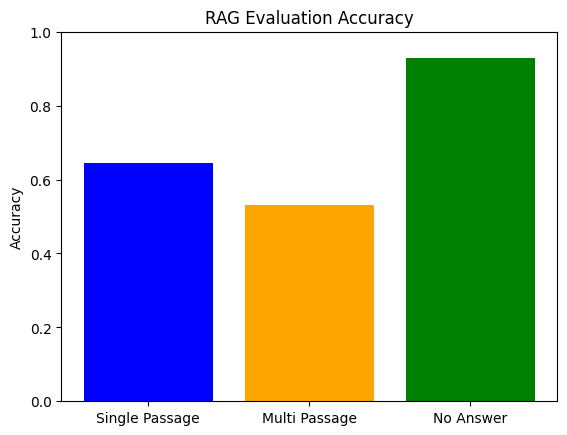

Single Passage Accuracy: 0.65   Mean: 3.23   Median: 4.0
Multi Passage Accuracy: 0.53   Mean: 2.65   Median: 3.0
No Answer Accuracy: 0.93   Mean: 4.65   Median: 5.0


In [45]:
# create a summary of the results

def summary(pd_result):
    total_questions = len(pd_result)
    score_sum = pd_result['score'].sum()
    accuracy = score_sum / (total_questions * 5) # each question is scored out of 5
    mean = pd_result['score'].mean()
    median = pd_result['score'].median()
    return {'accuracy': accuracy, 'mean': mean, 'median': median}

pd_single_passage_result = pd.read_csv(f'{results_directory}/single_passage_answer_questions_predict.csv')
single_passage_summary = summary(pd_single_passage_result)

pd_multi_passage_result = pd.read_csv(f'{results_directory}/multi_passage_answer_questions_predict.csv')
multi_passage_summary = summary(pd_multi_passage_result)

pd_no_answer_result = pd.read_csv(f'{results_directory}/no_answer_questions_predict.csv')
no_answer_summary = summary(pd_no_answer_result)


# create a plot of the accuracies
labels = ['Single Passage', 'Multi Passage', 'No Answer']
summary = [single_passage_summary, multi_passage_summary, no_answer_summary]

accuracies = [s['accuracy'] for s in summary]
plt.bar(labels, accuracies, color=['blue', 'orange', 'green'])
plt.ylim(0, 1)
plt.ylabel('Accuracy')
plt.title('RAG Evaluation Accuracy')
plt.show()

for i, s in enumerate(summary):
    print(f"{labels[i]} Accuracy: {s['accuracy']:.2f}   Mean: {s['mean']:.2f}   Median: {s['median']}")